In [ ]:
import torch
import torch.nn as nn
import torchvision.models
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import torch.nn.functional as F

import albumentations as A
from albumentations.pytorch import ToTensorV2

from tqdm import tqdm
from PIL import Image
import cv2
import matplotlib.pyplot as plt
import numpy as np

import os
from time import time

/usr/local/lib/python3.10/dist-packages/albumentations/__init__.py:13: UserWarning: A new version of Albumentations is available: 1.4.20 (you have 1.4.15). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


### Get the data

In [ ]:
import gdown
url = 'https://drive.google.com/uc?id=10f1H2T-5W-BiqabHHtlZ4ASs19TZmg8R'
output = 'data.zip'
gdown.download(url, output, quiet=False)

FileURLRetrievalError: Failed to retrieve file url:

	Too many users have viewed or downloaded this file recently. Please
	try accessing the file again later. If the file you are trying to
	access is particularly large or is shared with many people, it may
	take up to 24 hours to be able to view or download the file. If you
	still can't access a file after 24 hours, contact your domain
	administrator.

You may still be able to access the file from the browser:

	https://drive.google.com/uc?id=10f1H2T-5W-BiqabHHtlZ4ASs19TZmg8R

but Gdown can't. Please check connections and permissions.

In [ ]:
!ls

data.zip  sample_data


In [ ]:
!unzip data.zip

### Utilities (0.5 point)

Complete dataset to load prepared images and masks. Don't forget to use augmentations.

Some of the images are 1 channels, so use `gray2rgb`.

In [ ]:
for class_name in os.listdir("data/train/images"):
    for fname in os.listdir(os.path.join("data/train/images", class_name)):
        print(os.path.join(class_name, fname))

In [ ]:
def preprocess_mask(mask):
    mask = mask.astype(np.float32)
    mask[mask == 2.0] = 0.0
    mask[(mask == 1.0) | (mask == 3.0)] = 1.0
    return mask

In [ ]:
def gray2rgb(img):
    if len(img.shape) != 3:
        img = np.dstack([img, img, img])
    return img

def calc_iou(prediction, ground_truth):
    # YOUR CODE HERE

    n_images = len(prediction)
    intersection, union = [], []
    #prediction = prediction.to("cpu")
    #ground_truth = ground_truth.to("cpu")
    for i in range(n_images):
        intersection += [np.logical_and(prediction[i], ground_truth[i]).astype(np.float32).sum()]
        union += [np.logical_or(prediction[i], ground_truth[i]).astype(np.float32).sum()]
    return ((np.array(intersection) + 1e-7) / (np.array(union) + 1e-7)).sum()

class BirdsDataset(Dataset):
    def __init__(self, folder) -> None:
        self.folder = folder
        images_folder = os.path.join(folder, 'images')
        gt_folder = os.path.join(folder, 'gt')
        self.all_images = []

        for class_name in os.listdir(images_folder):
            for fname in os.listdir(os.path.join(images_folder, class_name)):
                self.all_images.append(os.path.join(class_name, fname))

        self.transform = A.Compose([
            A.Resize(256, 256),
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ToTensorV2()
        ])

    def __getitem__(self, index):
        current_image_name = self.all_images[index]
        img = cv2.imread(os.path.join(self.folder + "/images", current_image_name))
        mask = cv2.imread(os.path.join(self.folder + "/gt", current_image_name.replace(".jpg", ".png")), cv2.IMREAD_UNCHANGED)
        mask = preprocess_mask(mask)
        img = gray2rgb(img)

        transformed = self.transform(image=img, mask=mask)
        transformed_img = transformed["image"]
        transformed_mask = transformed["mask"]
        return transformed_img, transformed_mask

    def __len__(self):
        return len(self.all_images)

In [ ]:
from torchvision import models
fcn = models.segmentation.fcn_resnet50(pretrained=True).eval()

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FCN_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=FCN_ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/fcn_resnet50_coco-1167a1af.pth" to /root/.cache/torch/hub/checkpoints/fcn_resnet50_coco-1167a1af.pth
100%|██████████| 135M/135M [00:03<00:00, 44.0MB/s]


In [ ]:
fcn

FCN(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequenti

In [ ]:
dset = BirdsDataset("data/train")
print(len(dset))
expanded = fcn(dset[46][0].unsqueeze(0))
f, axarr = plt.subplots(2,1)
axarr[0].imshow(dset[46][0].T, interpolation='nearest')
axarr[1].imshow(expanded['out'][0][0].T.detach().numpy())
plt.show()

8382


NameError: name 'fcn' is not defined

### Architecture (1 point)
Your task for today is to build your own Unet to solve the segmentation problem.

As an encoder, you can use pre-trained on IMAGENET models(or parts) from torchvision. The decoder must be trained from scratch.
It is forbidden to use data not from the `data` folder.

I advise you to experiment with the number of blocks so as not to overfit on the training sample and get good quality on validation.

In [ ]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, padding=1, kernel_size=3, stride=1):
        super().__init__()
        # YOUR CODE HERE
        self.conv = nn.Conv2d(in_channels, out_channels, padding=padding, kernel_size=kernel_size, stride=stride)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()
    def forward(self, x):
        # YOUR CODE HERE
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)
        return x

class DoubleConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        # YOUR CODE HERE
        self.dconv = nn.Sequential(
            ConvBlock(in_channels, out_channels),
            ConvBlock(out_channels, out_channels)
        )

    def forward(self, x):
        # YOUR CODE HERE
        return self.dconv(x)

class UpConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, up_conv_in_channels=None, up_conv_out_channels=None):
        super().__init__()

        if up_conv_in_channels == None:
            up_conv_in_channels = in_channels
        if up_conv_out_channels == None:
            up_conv_out_channels = out_channels

        # YOUR CODE HERE
        # self.upsample = nn.ConvTranspose2d(up_conv_in_channels, up_conv_out_channels, kernel_size=2, stride=2)
        self.upsample = nn.Upsample(scale_factor=2)
        self.conv_block_1 = ConvBlock(in_channels, out_channels)
        self.conv_block_2 = ConvBlock(out_channels, out_channels)

    def forward(self, up_x, down_x):
        # YOUR CODE HERE
        x = self.upsample(up_x)
        x = torch.cat([x, down_x], dim=1)
        x = self.conv_block_1(x)
        x = self.conv_block_2(x)
        return x

class Unet(nn.Module):
    def __init__(self, n_classes=2, in_channels=3):
        super().__init__()
        # YOUR CODE HERE
        self.pooling = nn.MaxPool2d(2)
        self.inp = DoubleConvBlock(in_channels, 64)
        self.conv1 = Bottleneck(64)
        self.conv2 = Bottleneck(128)
        self.conv3 = Bottleneck(256)
        self.conv4 = Bottleneck(512)

        self.upconv1 = UpConvBlock(1024+512, 512)
        self.upconv2 = UpConvBlock(512+256, 256)
        self.upconv3 = UpConvBlock(256+128, 128)
        self.upconv4 = UpConvBlock(128+64, 64)

        self.out = nn.Sequential(
            nn.Conv2d(64, 1, kernel_size=1)
        )
    def forward(self, x):
        # YOUR CODE HERE

        x1 = self.inp(x)

        x2 = self.conv1(x1)

        x2 = self.pooling(x2)

        x3 = self.conv2(x2)
        x3 = self.pooling(x3)
        x4 = self.conv3(x3)
        x4 = self.pooling(x4)
        x5 = self.conv4(x4)
        x5 = self.pooling(x5)


        x = self.upconv1(x5, x4)
        x = self.upconv2(x, x3)
        x = self.upconv3(x, x2)
        x = self.upconv4(x, x1)
        x = self.out(x)
        return {'out': x}

NameError: name 'nn' is not defined

In [ ]:
class Bottleneck(nn.Module):
    def __init__(in_channels: int):
        self.conv_down = nn.Conv2d(in_channels, in_channels/2,  padding=1, kernel_size=3, stride=1)
        self.bn_down = nn.BatchNorm2d(in_channels/2)
        self.conv_flat = nn.Conv2d(in_channels/2, in_channels/2,  padding=1, kernel_size=3, stride=1)
        self.bn_flat = nn.BatchNorm2d(in_channels/2)
        self.conv_up = nn.Conv2d(in_channels/2, in_channels*2, padding=1, kernel_size=3, stride=1)
        self.bn_up = nn.BatchNorm2d(in_channels*2)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.conv_down(x)
        x = self.bn_down(x)
        x = self.conv_flat(x)
        x = self.bn_flat(x)
        x = self.conv_up(x)
        x = self.bn_up(x)
        x = self.relu(x)
        return x

class SkipConnection(nn.Module):
    def __init__(self):
        pass

    def forward(self, x1, x2):
        x = torch.cat([x1, x2], dim=1)
        return x

class KlyshnikovNet(nn.Module):
    def __init__(self):
        self.conv1 = nn.Conv2d(3, 64)
        self.b1 = Bottleneck(64) # out 128           <--\
        self.b2 = Bottleneck(128) # out 256             |
        self.b3 = Bottleneck(256) # out 512             |
        self.sc1 = SkipConnection() # out 512+128=640 --/
        self.b4 = Bottleneck(640) # out 1280
        self.conv2 = nn.Conv2d(1280, 1, kernel_size=1)

    def forward(x):
        x1 = self.conv1(x)
        x2 = self.b1(x1)
        x3 = self.b2(x2)
        x4 = self.b3(x3)
        x5 = self.sc1(x4, x2)
        x6 = self.b4(x5)
        x7 = self.conv2(x6)

        return {'out': x7}

### Train script (0.5 point)

Complete the train and predict scripts.

In [ ]:
def train_segmentation_model(model, data_path):
    print("Start")
    BATCH_SIZE = 4
    N_EPOCH = 15
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

    train_dataset = BirdsDataset(data_path + 'train')
    val_dataset = BirdsDataset(data_path + 'val')
    train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)


    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.BCEWithLogitsLoss().to(DEVICE)
    losses_train, losses_val, ious_train, ious_val = [], [], [], []

    for epoch in range(N_EPOCH):
        model.train()

        losses_each_batch = []
        ious_each_batch = []
        iou_total = 0
        loss_total = 0
        i_count = 0
        stream = tqdm(train_dataloader)
        for i, (inputs, masks) in enumerate(stream, start=1):
            i_count += 1
            inputs = inputs.to(DEVICE, non_blocking=True)
            masks = masks.to(DEVICE, non_blocking=True)

            output = model(inputs)['out'].squeeze(1)
            loss = criterion(output, masks)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            with torch.no_grad():
                iou_mean = np.mean(output.cpu().detach().numpy())
                iou_total = calc_iou(output.cpu().detach().numpy() > 0, masks.cpu().detach().numpy() > 224) / 4
                loss_total += loss.item()
                print(iou_total)
            #ious_each_batch.append(get_iou(masks, output))
        #print(sum(ious_each_batch)/len(ious_each_batch))
        losses_train.append(loss_total/i_count)
        #ious_train.append(sum(ious_each_batch) / len(ious_each_batch))

        model.eval()
        losses_each_batch = []
        ious_each_batch = []
        with torch.no_grad():
            for inputs, masks in tqdm(val_dataloader):
                inputs = inputs.to(DEVICE)
                masks = masks.to(DEVICE)
                output = model(inputs)['out'].squeeze(1)
                loss = criterion(output, masks)
                losses_each_batch.append(loss.item())
                #ious_each_batch.append(get_iou(masks, output))
        losses_val.append(sum(losses_each_batch) / len(losses_each_batch))
        #ious_val.append(sum(ious_each_batch) / len(ious_each_batch))

        torch.save(model.state_dict(), f'model_{epoch}.pth')

        print(f"Epoch: {epoch}, train loss: {losses_train[-1]}, val loss: {losses_val[-1]}")

In [ ]:
def predict(model, img_path):
    with torch.no_grad():
        image = cv2.imread(img_path);
        image = gray2rgb(image)

        transform = A.Compose([
            A.Resize(256, 256),
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ToTensorV2()
        ])

        transformed = transform(image=image)
        transformed_img = transformed["image"]

        output = model(transformed_img.unsqueeze(0))['out']
        #segm = torch.sigmoid(output.squeeze(1))
        return output

def get_model(path):
    model = Unet()
    model.load_state_dict(torch.load(path))
    model.eval()
    return model

In [ ]:
model = Unet().to('cpu')

In [ ]:
model = Unet().to('cpu')
train_segmentation_model(model, 'data/')

8382


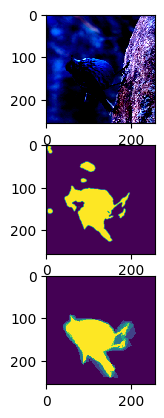

tensor(0.7361)


In [ ]:
dset = BirdsDataset("data/train")
print(len(dset))
x = 67

expanded = model(dset[x][0].unsqueeze(0))
f, axarr = plt.subplots(3,1)
axarr[0].imshow(dset[x][0].T, interpolation='nearest')
nnp = expanded['out'][0][0].T.detach().numpy()
nnp_mean = (np.max(nnp) + np.min(nnp)) / 2
nnp[nnp >= nnp_mean] = 255
nnp[nnp < nnp_mean] = 0
axarr[1].imshow(nnp)
axarr[2].imshow(dset[x][1].T, interpolation='nearest')
plt.show()

a = np.logical_and(expanded['out'][0][0].detach().numpy() > 0, dset[x][1] > 224)
b = np.logical_or(expanded['out'][0][0].detach().numpy() > 0, dset[x][1] > 224)
print(a.sum()/b.sum())

In [ ]:
tot = 0
for x in range(0, 2000, 5):
    print(x)
    expanded = model(dset[x][0].unsqueeze(0))
    nnp = expanded['out'][0][0].T.detach().numpy()
    nnp_mean = (np.max(nnp) + np.min(nnp)) / 2
    a = np.logical_and(expanded['out'][0][0].detach().numpy() > nnp_mean, dset[x][1] > 224)
    b = np.logical_or(expanded['out'][0][0].detach().numpy() > nnp_mean, dset[x][1] > 224)
    tot += (a.sum()/b.sum())
print(tot/2000)

In [ ]:
print(nnp[200] > 0)
print(dset[x][1][200] > 244)

You can also experiment with models and write a small report about results. If the report will be meaningful, you will receive an extra point.

### Testing (8 points)
Your model will be tested on the new data, similar to validation, so use techniques to prevent overfitting the model.

* IoU > 0.85 — 8 points
* IoU > 0.80 — 7 points
* IoU > 0.75 — 6 points
* IoU > 0.70 — 5 points
* IoU > 0.60 — 4 points
* IoU > 0.50 — 3 points
* IoU > 0.40 — 2 points
* IoU > 0.30 — 1 points

In [ ]:
model = get_model('model_14.pth').to('cuda')

In [ ]:
ious, times = [], []
test_dir = 'data/val/'

for class_name in tqdm(sorted(os.listdir(os.path.join(test_dir, 'images')))):
    for img_name in sorted(os.listdir(os.path.join(test_dir, 'images', class_name))):

        t_start = time()
        pred = predict(model, os.path.join(test_dir, 'images', class_name, img_name))
        times.append(time() - t_start)

        gt_name = img_name.replace('jpg', 'png')
        gt = np.asarray(Image.open(os.path.join(test_dir, 'gt', class_name, gt_name)), dtype = np.uint8)
        if len(gt.shape) > 2:
            gt = gt[:, :, 0]

        transform = A.Compose([
            A.Resize(256, 256),
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ToTensorV2()
        ])

        transformed = transform(image=gt)
        transformed_gt = transformed["image"]

        iou_mean = np.mean(pred.cpu().detach().numpy())
        iou = calc_iou(pred.detach().numpy()>=iou_mean, transformed_gt.detach().numpy() > 244)
        ious.append(iou)

np.mean(ious), np.mean(times)

 14%|█▍        | 29/200 [12:25<1:13:16, 25.71s/it]


KeyboardInterrupt: 

### Compression (1 point)

Try to speed up the model in any way without losing more than 1% in iou score.
For example [torch2trt](https://github.com/NVIDIA-AI-IOT/torch2trt)

In [ ]:
def get_fast_model():
    # YOUR CODE HERE
    return model

In [ ]:
fast_model = get_fast_model().to('cuda')

In [ ]:
ious, times = [], []
test_dir = 'data/val/'

for class_name in tqdm(sorted(os.listdir(os.path.join(test_dir, 'images')))):
    for img_name in sorted(os.listdir(os.path.join(test_dir, 'images', class_name))):

        t_start = time()
        pred = predict(fast_model, os.path.join(test_dir, 'images', class_name, img_name))
        times.append(time() - t_start)

        gt_name = img_name.replace('jpg', 'png')
        gt = np.asarray(Image.open(os.path.join(test_dir, 'gt', class_name, gt_name)), dtype = np.uint8)
        if len(gt.shape) > 2:
            gt = gt[:, :, 0]

        iou = get_iou(gt==255, pred>0.5)
        ious.append(iou)

np.mean(ious), np.mean(times)

**Bonus:** For the best iou score on test(without compression) in group you will get 1.5, 1, 0.5 extra points(for 1st, 2nd, 3rd places).